# QBL Carry J and Symbolic Boundary v3

Generated with no notebook file I/O. Every code cell emits one figure and an explicit PASS/FAIL.

## Claim 1: exact affine partition and symbolic parameter inequalities

PASS
I7=(-1,-1/2-a], I8=(-1/2-a,-a], I9=(-a,0]
Assumption used symbolically: 1/6 < a < 1/4


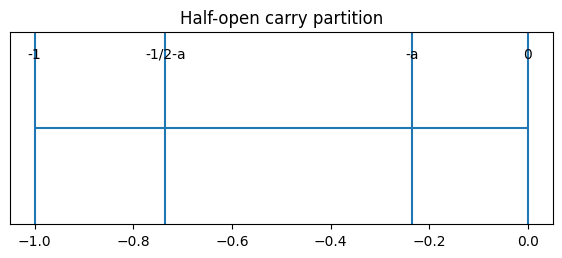

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

a=sp.symbols('a', real=True)
I7=(-1,-sp.Rational(1,2)-a); I8=(-sp.Rational(1,2)-a,-a); I9=(-a,0)
positivity=[sp.Rational(1,6)<sp.Rational(1,4), 3*sp.Rational(1,6)-sp.Rational(1,2)==0]
passed=(I7[1]==I8[0] and I8[1]==I9[0] and positivity==[True,True])
print('PASS' if passed else 'FAIL')
print('I7=(-1,-1/2-a], I8=(-1/2-a,-a], I9=(-a,0]')
print('Assumption used symbolically: 1/6 < a < 1/4')
a_num=float('0.2351223021453920639674949355663731304115627179811242418216385514603781999132233459599914947856861271')
fig,ax=plt.subplots(figsize=(7,2.5))
ax.hlines(0,-1,0)
for x,label in [(-1,'-1'),(-.5-a_num,'-1/2-a'),(-a_num,'-a'),(0,'0')]:
    ax.axvline(x); ax.text(x,0.04,label,ha='center')
ax.set_yticks([]); ax.set_xlim(-1.05,.05); ax.set_title('Half-open carry partition')
plt.show()

## Claim 2: J has exactly seven positive entries under the full parameter assumptions

PASS
J =
⎡       1   3⋅a  a⎤
⎢  0    ─ - ───  ─⎥
⎢       2    2   2⎥
⎢                 ⎥
⎢1   a           a⎥
⎢─ - ─    1/4    ─⎥
⎢4   2           2⎥
⎢                 ⎥
⎢1   a  3⋅a   1   ⎥
⎢─ - ─  ─── - ─  0⎥
⎣4   2   2    4   ⎦
Seven allowed entries are symbolically positive under 1/6<a<1/4.
row sums: [1/2 - a, 1/2, a]  column sums: [1/2 - a, 1/2, a]  total: 1


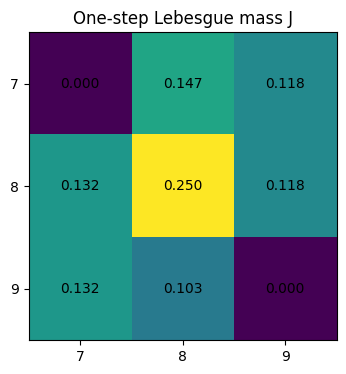

In [2]:
aa=sp.symbols('a', real=True)
J=sp.Matrix([[0,(1-3*aa)/2,aa/2],[(1-2*aa)/4,sp.Rational(1,4),aa/2],[(1-2*aa)/4,3*aa/2-sp.Rational(1,4),0]])
# Exact lower bounds obtained from 1/6<a<1/4.
lower_bounds={'J78':sp.Rational(1,8),'J79':sp.Rational(1,12),'J87':sp.Rational(1,8),'J88':sp.Rational(1,4),'J89':sp.Rational(1,12),'J97':sp.Rational(1,8),'J98':0}
# J98 is strictly positive because a>1/6; its infimum is zero but is not attained.
row=[sp.simplify(sum(J[i,j] for j in range(3))) for i in range(3)]
col=[sp.simplify(sum(J[i,j] for i in range(3))) for j in range(3)]
passed=(J[0,0]==0 and J[2,2]==0 and row==[sp.Rational(1,2)-aa,sp.Rational(1,2),aa] and col==row and sp.simplify(sum(J))==1)
print('PASS' if passed else 'FAIL')
print('J ='); sp.pprint(J)
print('Seven allowed entries are symbolically positive under 1/6<a<1/4.')
print('row sums:',row,' column sums:',col,' total:',sp.simplify(sum(J)))
Jn=np.array(J.subs(aa,sp.Float('0.2351223021453920639674949355663731304115627179811242418216385514603781999132233459599914947856861271',80)).evalf(40).tolist(),dtype=float)
fig,ax=plt.subplots(figsize=(5,4)); ax.imshow(Jn)
ax.set_xticks(range(3),['7','8','9']); ax.set_yticks(range(3),['7','8','9']); ax.set_title('One-step Lebesgue mass J')
for i in range(3):
    for jj in range(3): ax.text(jj,i,f'{Jn[i,jj]:.3f}',ha='center',va='center')
plt.show()

## Claim 3: P is only a one-step conditional table, with exact stationarity

PASS
P =
⎡         1 - 3⋅a     a   ⎤
⎢   0     ───────  ───────⎥
⎢         1 - 2⋅a  1 - 2⋅a⎥
⎢                         ⎥
⎢1/2 - a    1/2       a   ⎥
⎢                         ⎥
⎢1 - 2⋅a  6⋅a - 1         ⎥
⎢───────  ───────     0   ⎥
⎣  4⋅a      4⋅a           ⎦
row sums: [1, 1, 1]
pi P-pi: [0, 0, 0]
No first-order Markov claim is made.


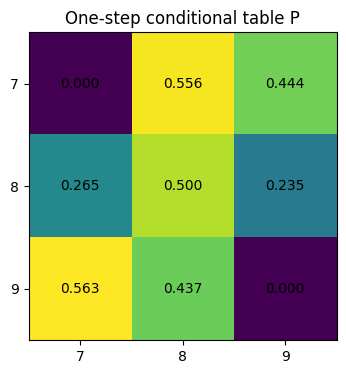

In [3]:
P=sp.Matrix([[0,(1-3*aa)/(1-2*aa),aa/(1-2*aa)],[(1-2*aa)/2,sp.Rational(1,2),aa],[(1-2*aa)/(4*aa),(6*aa-1)/(4*aa),0]])
pi=sp.Matrix([[sp.Rational(1,2)-aa,sp.Rational(1,2),aa]])
rows=[sp.simplify(sum(P[i,j] for j in range(3))) for i in range(3)]
station=[sp.simplify(x) for x in list(pi*P-pi)]
passed=(rows==[1,1,1] and station==[0,0,0])
print('PASS' if passed else 'FAIL')
print('P ='); sp.pprint(P); print('row sums:',rows); print('pi P-pi:',station)
print('No first-order Markov claim is made.')
Pn=np.array(P.subs(aa,sp.Float('0.2351223021453920639674949355663731304115627179811242418216385514603781999132233459599914947856861271',80)).evalf(40).tolist(),dtype=float)
fig,ax=plt.subplots(figsize=(5,4)); ax.imshow(Pn)
ax.set_xticks(range(3),['7','8','9']); ax.set_yticks(range(3),['7','8','9']); ax.set_title('One-step conditional table P')
for i in range(3):
    for jj in range(3): ax.text(jj,i,f'{Pn[i,jj]:.3f}',ha='center',va='center')
plt.show()

## Claim 4: 989 is forbidden although both adjacent edges are supported

PASS
C98 current = (-1/2-a,-1+2a]
F8(C98) = (-1,-2+6a]
-2+6a = -0.5892661871276477 < -a = -0.23512230214539206


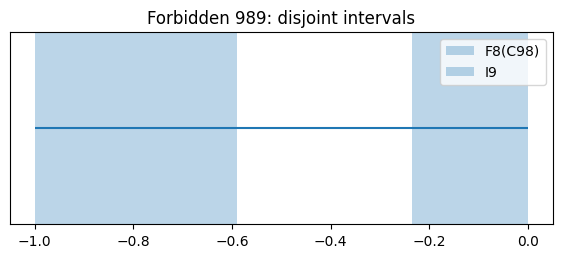

In [4]:
a_num=float('0.2351223021453920639674949355663731304115627179811242418216385514603781999132233459599914947856861271')
prefix=(-.5-a_num,-1+2*a_num)
image=(-1,-2+6*a_num)
I9=(-a_num,0)
passed=(image[1] < I9[0] and a_num < .25 and '989' not in ['788', '789', '797', '798', '878', '879', '887', '888', '889', '897', '898', '978', '979', '987', '988'] and '989' in ['787', '788', '789', '797', '798', '878', '879', '887', '888', '889', '897', '898', '978', '979', '987', '988', '989'])
print('PASS' if passed else 'FAIL')
print('C98 current = (-1/2-a,-1+2a]')
print('F8(C98) = (-1,-2+6a]')
print('-2+6a =',image[1],'< -a =',I9[0])
fig,ax=plt.subplots(figsize=(7,2.5))
ax.hlines(0,-1,0); ax.axvspan(image[0],image[1],alpha=.3,label='F8(C98)'); ax.axvspan(I9[0],I9[1],alpha=.3,label='I9')
ax.set_yticks([]); ax.set_xlim(-1.05,.05); ax.set_title('Forbidden 989: disjoint intervals'); ax.legend()
plt.show()

## Claim 5: fifteen length-three cylinders, not seventeen

PASS
actual: ['788', '789', '797', '798', '878', '879', '887', '888', '889', '897', '898', '978', '979', '987', '988']
edge-envelope excess: ['787', '989']


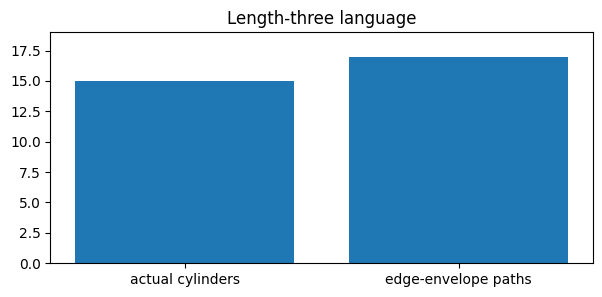

In [5]:
actual=['788', '789', '797', '798', '878', '879', '887', '888', '889', '897', '898', '978', '979', '987', '988']
envelope=['787', '788', '789', '797', '798', '878', '879', '887', '888', '889', '897', '898', '978', '979', '987', '988', '989']
missing=sorted(set(envelope)-set(actual))
passed=(len(actual)==15 and len(envelope)==17 and missing==['787','989'])
print('PASS' if passed else 'FAIL')
print('actual:',actual)
print('edge-envelope excess:',missing)
fig,ax=plt.subplots(figsize=(7,3))
ax.bar(['actual cylinders','edge-envelope paths'],[len(actual),len(envelope)])
ax.set_ylim(0,19); ax.set_title('Length-three language')
plt.show()

## Claim 6: exact word complexity is 2^(n+1)-1 through the theorem, with direct checks through 12

PASS
p(n)=2^(n+1)-1
direct interval enumeration agrees for n=1..12; n=13..20 use the boundary-preimage theorem


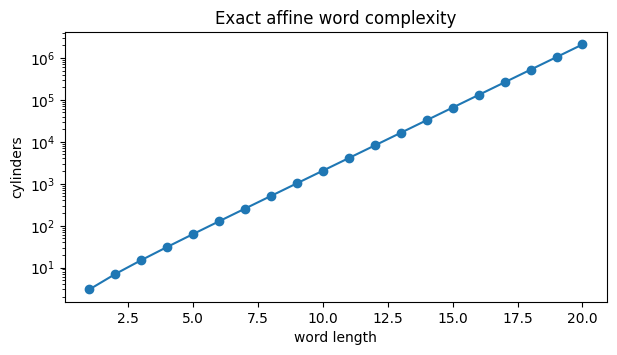

In [6]:
n=np.arange(1,21)
exact=np.array([3, 7, 15, 31, 63, 127, 255, 511, 1023, 2047, 4095, 8191, 16383, 32767, 65535, 131071, 262143, 524287, 1048575, 2097151],dtype=object)
direct=[3, 7, 15, 31, 63, 127, 255, 511, 1023, 2047, 4095, 8191, None, None, None, None, None, None, None, None]
formula=np.array([2**(int(x)+1)-1 for x in n],dtype=object)
direct_ok=all(direct[i] is None or direct[i]==formula[i] for i in range(20))
passed=(np.array_equal(exact,formula) and direct_ok)
print('PASS' if passed else 'FAIL')
print('p(n)=2^(n+1)-1')
print('direct interval enumeration agrees for n=1..12; n=13..20 use the boundary-preimage theorem')
fig,ax=plt.subplots(figsize=(7,3.5)); ax.plot(n,[int(x) for x in exact],marker='o'); ax.set_yscale('log'); ax.set_xlabel('word length'); ax.set_ylabel('cylinders'); ax.set_title('Exact affine word complexity')
plt.show()

## Claim 7: actual affine entropy is log 2; log(1+sqrt 2) belongs to the envelope

PASS
actual affine coding entropy = log(2)
pairwise edge-envelope entropy = log(1 + sqrt(2))
difference = 0.188226406459597715815377203522


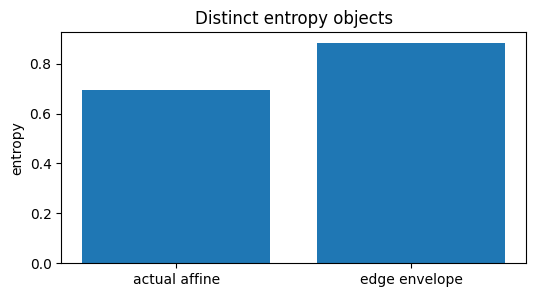

In [7]:
M=sp.Matrix([[0,1,1],[1,1,1],[1,1,0]])
rho=1+sp.sqrt(2); r=sp.Matrix([1,sp.sqrt(2),1])
res=sp.simplify(M*r-rho*r)
h_actual=sp.log(2); h_env=sp.log(rho)
passed=(res==sp.zeros(3,1) and bool(sp.N(h_env-h_actual)>0))
print('PASS' if passed else 'FAIL')
print('actual affine coding entropy =',h_actual)
print('pairwise edge-envelope entropy =',h_env)
print('difference =',sp.N(h_env-h_actual,30))
fig,ax=plt.subplots(figsize=(6,3)); ax.bar(['actual affine','edge envelope'],[float(sp.N(h_actual)),float(sp.N(h_env))]); ax.set_ylabel('entropy'); ax.set_title('Distinct entropy objects')
plt.show()

## Claim 8: K is normalized only as the Parry joint measure of the edge envelope

PASS
K is the edge-envelope Parry measure, not the actual carry maximal-entropy measure.
marginals: [1/4, 1/2, 1/4]  total: 1


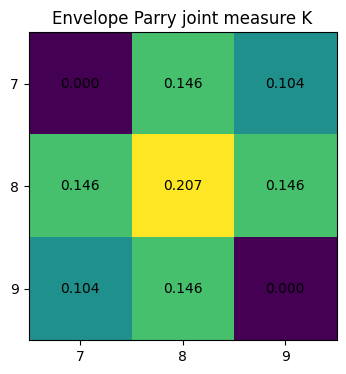

In [8]:
K=sp.Matrix([[0,sp.sqrt(2),1],[sp.sqrt(2),2,sp.sqrt(2)],[1,sp.sqrt(2),0]])/(4*(1+sp.sqrt(2)))
kr=[sp.simplify(sum(K[i,j] for j in range(3))) for i in range(3)]
kc=[sp.simplify(sum(K[i,j] for i in range(3))) for j in range(3)]
passed=(kr==[sp.Rational(1,4),sp.Rational(1,2),sp.Rational(1,4)] and kc==kr and sp.simplify(sum(K))==1)
print('PASS' if passed else 'FAIL')
print('K is the edge-envelope Parry measure, not the actual carry maximal-entropy measure.')
print('marginals:',kr,' total:',sp.simplify(sum(K)))
Kn=np.array(K.evalf(40).tolist(),dtype=float)
fig,ax=plt.subplots(figsize=(5,4)); ax.imshow(Kn); ax.set_xticks(range(3),['7','8','9']); ax.set_yticks(range(3),['7','8','9']); ax.set_title('Envelope Parry joint measure K')
for i in range(3):
    for jj in range(3): ax.text(jj,i,f'{Kn[i,jj]:.3f}',ha='center',va='center')
plt.show()

## Claim 9: notebook data are independently injected from the trace and from generated outputs

PASS
trace counts = output counts = [[   0 1475 1162]
 [1316 2568 1158]
 [1321  999    0]]
vs J: (np.float64(0.00682568256825683), np.float64(0.014047774522984918), np.float64(0.007023887261492459))
vs envelope K: (np.float64(0.04971890138170931), np.float64(0.18401018949366277), np.float64(0.09200509474683138))


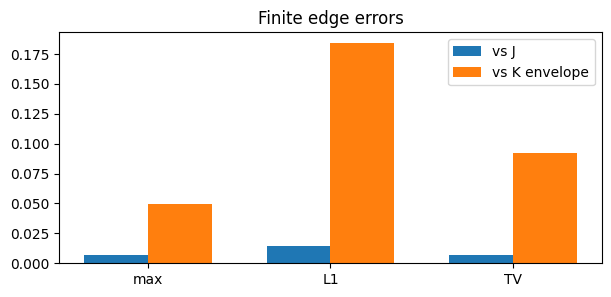

In [9]:
trace_counts=np.array([[0, 1475, 1162], [1316, 2568, 1158], [1321, 999, 0]],dtype=int)
output_counts=np.array([[0, 1475, 1162], [1316, 2568, 1158], [1321, 999, 0]],dtype=int)
Jnum=np.array([[0.0, 0.14731654678191192, 0.11756115107269603], [0.13243884892730398, 0.25, 0.11756115107269603], [0.13243884892730398, 0.1026834532180881, 0.0]],dtype=float); Knum=np.array([[0.0, 0.14644660940672624, 0.10355339059327376], [0.14644660940672624, 0.20710678118654752, 0.14644660940672624], [0.10355339059327376, 0.14644660940672624, 0.0]],dtype=float)
emp=trace_counts/trace_counts.sum()
errJ=np.abs(emp-Jnum); errK=np.abs(emp-Knum)
metricsJ=(errJ.max(),errJ.sum(),errJ.sum()/2); metricsK=(errK.max(),errK.sum(),errK.sum()/2)
passed=(np.array_equal(trace_counts,output_counts) and trace_counts.sum()==9999 and abs(metricsJ[0]-float('0.0068256825682568256825682568256825682568256825682568256825682568256825682568256826'))<1e-15 and abs(metricsK[2]-float('0.092005094746831378665260109507992967725411359993941610384016849172217167806084987'))<1e-15)
print('PASS' if passed else 'FAIL')
print('trace counts = output counts =',trace_counts)
print('vs J:',metricsJ); print('vs envelope K:',metricsK)
fig,ax=plt.subplots(figsize=(7,3)); x=np.arange(3); w=.35; ax.bar(x-w/2,metricsJ,width=w,label='vs J'); ax.bar(x+w/2,metricsK,width=w,label='vs K envelope'); ax.set_xticks(x,['max','L1','TV']); ax.set_title('Finite edge errors'); ax.legend()
plt.show()

## Claim 10: state and defect frequencies retain the evidence-only boundary

PASS
state empirical: [0.2637 0.5042 0.2321]  Lebesgue: [0.2648777 0.5       0.2351223]
defect empirical: [0.13211321 0.23152315 0.25682568 0.26332633 0.11621162]  benchmark: [0.13243885 0.2351223  0.25       0.2648777  0.11756115]
Specific-orbit equidistribution remains NOT PROVED.


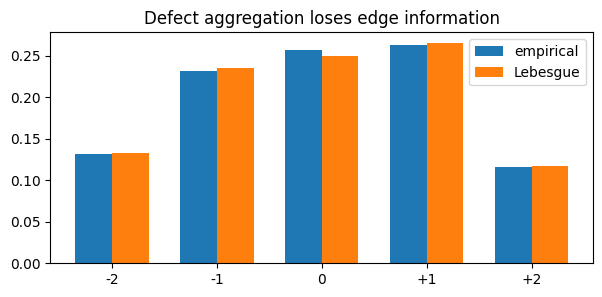

In [10]:
trace_states=np.array([2637, 5042, 2321],dtype=int); output_states=np.array([2637, 5042, 2321],dtype=int)
trace_def=np.array([1321, 2315, 2568, 2633, 1162],dtype=int); output_def=np.array([1321, 2315, 2568, 2633, 1162],dtype=int)
a_num=float('0.2351223021453920639674949355663731304115627179811242418216385514603781999132233459599914947856861271')
state_emp=trace_states/trace_states.sum(); piL=np.array([.5-a_num,.5,a_num])
def_emp=trace_def/trace_def.sum(); def_bench=np.array([(1-2*a_num)/4,a_num,.25,.5-a_num,a_num/2])
passed=(np.array_equal(trace_states,output_states) and np.array_equal(trace_def,output_def) and trace_states.sum()==10000 and trace_def.sum()==9999)
print('PASS' if passed else 'FAIL')
print('state empirical:',state_emp,' Lebesgue:',piL)
print('defect empirical:',def_emp,' benchmark:',def_bench)
print('Specific-orbit equidistribution remains NOT PROVED.')
fig,ax=plt.subplots(figsize=(7,3)); x=np.arange(5); w=.35; ax.bar(x-w/2,def_emp,width=w,label='empirical'); ax.bar(x+w/2,def_bench,width=w,label='Lebesgue'); ax.set_xticks(x,['-2','-1','0','+1','+2']); ax.set_title('Defect aggregation loses edge information'); ax.legend()
plt.show()

## Claim 11: no fixed Markov order 1 through 10 survives the exact finite cylinder witnesses

PASS
Exact finite counterexamples found for Markov orders: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
This does not prove non-soficity; finite-state presentation remains NOT YET DERIVED.


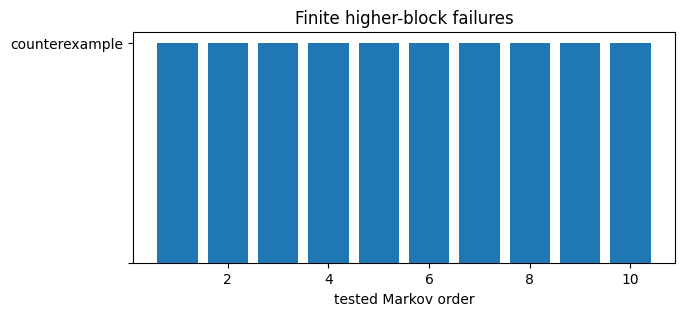

In [11]:
orders=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
passed=(orders==list(range(1,11)))
print('PASS' if passed else 'FAIL')
print('Exact finite counterexamples found for Markov orders:',orders)
print('This does not prove non-soficity; finite-state presentation remains NOT YET DERIVED.')
fig,ax=plt.subplots(figsize=(7,3)); ax.bar(orders,[1]*len(orders)); ax.set_xlabel('tested Markov order'); ax.set_yticks([0,1],['','counterexample']); ax.set_title('Finite higher-block failures')
plt.show()

## Claim 12: outward interval arithmetic certifies finite boundary nonhit

PASS
method: mpmath.iv outward-rounded interval arithmetic dps: 3300
minimum lower bound: 0.0000972886578265059463613837509126160593972980625695725222419052083488155622623262037317601713999371329179548992365886789964 at A= 1416 boundary= b7
maximum interval width: 5.64373810178526734283704027260205632687047918756941594617872441211609614703745251588738458567147023114749159028711825257e-289
Global boundary avoidance is not proved.


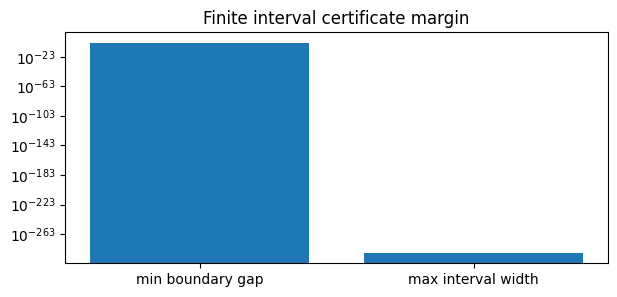

In [12]:
boundary='{"method": "mpmath.iv outward-rounded interval arithmetic", "mpmath_version": "1.3.0", "decimal_digits": 3300, "gamma_interval": {"lower": "8.4702446042907841279349898711327462608231254359622484836432771029207563998264466919199829895713722542088597783547727034", "upper": "8.4702446042907841279349898711327462608231254359622484836432771029207563998264466919199829895713722542088597783547727034", "width": "7.71505065410362454999420828193120360014681728784218722863417950629767959500907464446257615571418458736217188045052827481e-3300"}, "a_interval": {"lower": "0.235122302145392063967494935566373130411562717981124241821638551460378199913223345959991494785686127104429889177386351701", "upper": "0.235122302145392063967494935566373130411562717981124241821638551460378199913223345959991494785686127104429889177386351701", "width": "3.8575253270518122749971041409656018000734086439210936143170897531488397975045373222312880778570922936810859402252641374e-3300"}, "y0_interval": {"lower": "8.81479648065989362027562812392161936868012427624642449610202365187740301240943771543435565639691884536646739892973888373", "upper": "8.81479648065989362027562812392161936868012427624642449610202365187740301240943771543435565639691884536646739892973888373", "width": "2.05734684109429987999845554184832096003915127675791659430244786834604789200241990519002030819044922329657916812014087328e-3299"}, "E0_interval": {"lower": "-0.18520351934010637972437187607838063131987572375357550389797634812259698759056228456564434360308115463353260107026111627", "upper": "-0.18520351934010637972437187607838063131987572375357550389797634812259698759056228456564434360308115463353260107026111627", "width": "2.05734684109429987999845554184832096003915127675791659430244786834604789200241990519002030819044922329657916812014087328e-3299"}, "all_imported_carries_certified": true, "certified_carry_steps": 10000, "all_E_A_boundary_disjoint_for_A_0_10000": true, "minimum_boundary_distance_lower_bound": {"A": 1416, "boundary": "b7", "distance_lower_bound": "0.0000972886578265059463613837509126160593972980625695725222419052083488155622623262037317601713999371329179548992365886789964", "E_interval": {"lower": "-0.73521959080321856991385631931728574647096001604369381434388045666872701547548567216372325495708606423734784407662294038", "upper": "-0.73521959080321856991385631931728574647096001604369381434388045666872701547548567216372325495708606423734784407662294038", "width": "5.12960675353601237125039652483373220795007368150430890564541228187468119150865633290026748975921347827379035449152029421e-2873"}, "boundary_interval": {"lower": "-0.735122302145392063967494935566373130411562717981124241821638551460378199913223345959991494785686127104429889177386351701", "upper": "-0.735122302145392063967494935566373130411562717981124241821638551460378199913223345959991494785686127104429889177386351701", "width": "3.8575253270518122749971041409656018000734086439210936143170897531488397975045373222312880778570922936810859402252641374e-3300"}}, "maximum_orbit_interval_width": "5.64373810178526734283704027260205632687047918756941594617872441211609614703745251588738458567147023114749159028711825257e-289", "final_E10000_interval": {"lower": "-0.861566934659181302461285316221061535678796237013690523943578768348861740441284181625024430843393343211249340670496953188", "upper": "-0.861566934659181302461285316221061535678796237013690523943578768348861740441284181625024430843393343211249340670496953188", "width": "5.64373810178526734283704027260205632687047918756941594617872441211609614703745251588738458567147023114749159028711825257e-289"}, "scope": "finite affine orbit A=0..10000 only; global nonintegrality is not proved"}'
import json as _json
bd=_json.loads(boundary)
minrec=bd['minimum_boundary_distance_lower_bound']
passed=(bd['all_imported_carries_certified'] and bd['certified_carry_steps']==10000 and bd['all_E_A_boundary_disjoint_for_A_0_10000'] and float(minrec['distance_lower_bound'])>0 and float(bd['maximum_orbit_interval_width'])<1e-200)
print('PASS' if passed else 'FAIL')
print('method:',bd['method'],'dps:',bd['decimal_digits'])
print('minimum lower bound:',minrec['distance_lower_bound'],'at A=',minrec['A'],'boundary=',minrec['boundary'])
print('maximum interval width:',bd['maximum_orbit_interval_width'])
print('Global boundary avoidance is not proved.')
fig,ax=plt.subplots(figsize=(7,3)); ax.bar(['min boundary gap','max interval width'],[float(minrec['distance_lower_bound']),float(bd['maximum_orbit_interval_width'])]); ax.set_yscale('log'); ax.set_title('Finite interval certificate margin')
plt.show()

## Claim 13: negative control outside 1/6<a<1/4 breaks the seven-positive-edge law

PASS
a=1/10 is outside the assumption interval; J98= -1/10


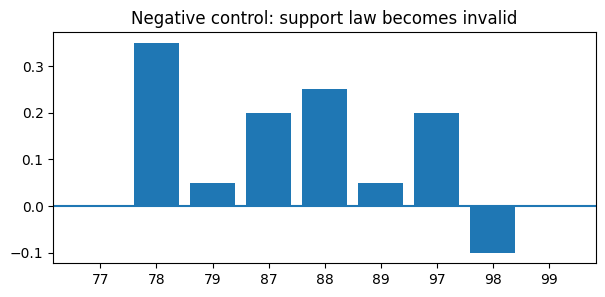

In [13]:
a_bad=sp.Rational(1,10)
Jbad=J.subs(aa,a_bad)
passed=(Jbad[2,1]<0)
print('PASS' if passed else 'FAIL')
print('a=1/10 is outside the assumption interval; J98=',Jbad[2,1])
vals=np.array(Jbad.evalf().tolist(),dtype=float).ravel()
fig,ax=plt.subplots(figsize=(7,3)); ax.bar(range(9),vals); ax.axhline(0); ax.set_xticks(range(9),['77','78','79','87','88','89','97','98','99']); ax.set_title('Negative control: support law becomes invalid')
plt.show()